In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from math import sqrt
import ROOT
import ctypes
try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style") 
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

from matplotlib.ticker import ScalarFormatter


Welcome to JupyROOT 6.26/04


In [2]:
def cal_Br_Central_value(Nsig, Nref, eff_sig, eff_ref, Br_ref_dec):
    print("Input values:")
    print("Nsig:", Nsig)
    print("Nref:", Nref)
    print("eff_sig:", eff_sig)
    print("eff_ref:", eff_ref)
    print("Br_ref_dec:", Br_ref_dec)
    
    N_real_sig = Nsig / eff_sig
    N_real_ref = Nref / eff_ref
    
    Br = Br_ref_dec * (N_real_sig / N_real_ref)
    
    return Br
    
from math import sqrt

def cal_Br_error_stat(Nsig_err, Nsig, Nref_err, Nref, central_value):
    Variance = (Nsig_err / Nsig)**2 + (Nref_err / Nref)**2
    TOTAL = sqrt(Variance) * central_value
    return TOTAL

def cal_Br_error_with_eff(Nsig_err, Nsig, Nref_err, Nref, eff_sig_err, eff_sig, eff_ref_err, eff_ref, central_value):
    Variance = (Nsig_err / Nsig)**2 + (eff_sig_err / eff_sig)**2 + (Nref_err / Nref)**2 + (eff_ref_err / eff_ref)**2
    TOTAL = sqrt(Variance) * central_value
    return TOTAL


In [3]:
from math import sqrt

# Function to calculate the central branching ratio value
def calculate_br(Nsig, Nref, eff_sig, eff_ref, Br_ref_dec):
    N_real_sig = Nsig / eff_sig
    N_real_ref = Nref / eff_ref
    Br = Br_ref_dec * (N_real_sig / N_real_ref)
    return Br

# Function to calculate statistical uncertainty
def calculate_stat_uncertainty(Nsig_err, Nsig, Nref_err, Nref, central_value):
    variance = (Nsig_err / Nsig)**2 + (Nref_err / Nref)**2
    return sqrt(variance) * central_value

# Function to print results in a formatted way
def print_results(label, central_value, stat_unc, Br_sig_dec):
    pull = (central_value - Br_sig_dec) / stat_unc
    print(f'{label} Central value = {central_value:.4e}')
    print(f'{label} Statistical uncertainty = {stat_unc:.4e}')
    print(f'{label} Pull = {pull:.4f}')
    print(f'{label} stas. unc./Central value = {stat_unc/central_value:.4e}\n')

# Error-weighted combination function
def combine_error_weighted(x, y, x_err, y_err):
    central_value = (x / x_err**2 + y / y_err**2) / (1 / x_err**2 + 1 / y_err**2)
    error = 1 / sqrt(1 / x_err**2 + 1 / y_err**2)
    return central_value, error

In [4]:
# signal_eff_error = math.sqrt(signal_eff * (1 - signal_eff) / N_gen)

def calculate_sig_eff_err(eff, N_gen):

    error = math.sqrt(eff * (1 - eff) / N_gen)
    return error

# Br(D+ -> eta K+)

In [76]:
# Constants
Br_ref_dec = 0.003770000
Br_sig_dec = 0.000125000

Br_sig_PDG = 0.0001250000
Br_sig_PDG_err = 0.0000160000


In [77]:
# # 0.92
# eff_sig_cal =  0.043206
# eff_ref_cal = 0.060058

In [78]:
# 0.96
eff_sig_cal =  0.027031
eff_ref_cal = 0.038254

In [79]:


eff_sig_err_cal = calculate_sig_eff_err(eff_sig_cal, 6e+6)

eff_sig_err_cal


eff_ref_err_cal = calculate_sig_eff_err(eff_ref_cal, 6e+6)
eff_ref_err_cal

print(f"signal eff error: {eff_sig_err_cal:.6e}, ref eff error: {eff_ref_err_cal:.6e}")

signal eff error: 6.620716e-05, ref eff error: 7.830563e-05


In [80]:
# First calculation for mode: eta -> gg
# Nsig_err, Nsig, Nref_err, Nref = 40.948915326744526, 505.2309140857891, 210.75266551658024, 21882.42868755736
Nsig_err, Nsig, Nref_err, Nref = 26.30248365406237, 293.368758593197,161.1838936135182 ,14086.38519122256

eff_sig_err, eff_sig, eff_ref_err, eff_ref = eff_sig_err_cal, eff_sig_cal, eff_ref_err_cal, eff_ref_cal

central_value_1 = calculate_br(Nsig, Nref, eff_sig, eff_ref, Br_ref_dec)
stat_unc_1 = calculate_stat_uncertainty(Nsig_err, Nsig, Nref_err, Nref, central_value_1)
print_results("Mode: eta -> gg", central_value_1, stat_unc_1, Br_sig_dec)


Mode: eta -> gg Central value = 1.1111e-04
Mode: eta -> gg Statistical uncertainty = 1.0043e-05
Mode: eta -> gg Pull = -1.3826
Mode: eta -> gg stas. unc./Central value = 9.0384e-02



In [81]:
# 0.88
eff_sig_cal =  0.045692
eff_ref_cal = 0.061975

In [82]:
# # 0.96
# eff_sig_cal =   0.023697
# eff_ref_cal =   0.033935

In [83]:
eff_sig_err_cal = calculate_sig_eff_err(eff_sig_cal, 6e+6)

eff_ref_err_cal = calculate_sig_eff_err(eff_ref_cal, 6e+6)

print(f"signal eff error: {eff_sig_err_cal:.6e}, ref eff error: {eff_ref_err_cal:.6e}")

signal eff error: 8.524889e-05, ref eff error: 9.843280e-05


In [84]:
# Second calculation for mode: eta -> pipipi
# Nsig_err, Nsig, Nref_err, Nref = 27.852663370508765, 317.5894750716714,139.4450508362106 ,13532.203228377544
Nsig_err, Nsig, Nref_err, Nref =16.045203521001085, 168.8763707860821, 97.28516231601725,7407.285773417721

eff_sig_err, eff_sig, eff_ref_err, eff_ref = eff_sig_err_cal, eff_sig_cal ,eff_ref_err_cal,eff_ref_cal

central_value_2 = calculate_br(Nsig, Nref, eff_sig, eff_ref, Br_ref_dec)
stat_unc_2 = calculate_stat_uncertainty(Nsig_err, Nsig, Nref_err, Nref, central_value_2)
print_results("Mode: eta -> pipipi", central_value_2, stat_unc_2, Br_sig_dec)

Mode: eta -> pipipi Central value = 1.1658e-04
Mode: eta -> pipipi Statistical uncertainty = 1.1182e-05
Mode: eta -> pipipi Pull = -0.7529
Mode: eta -> pipipi stas. unc./Central value = 9.5915e-02



In [85]:
# Combined error-weighted result
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)
print_results("Combined", combined_central_value, combined_error, Br_sig_dec)

Combined Central value = 1.1356e-04
Combined Statistical uncertainty = 7.4718e-06
Combined Pull = -1.5317
Combined stas. unc./Central value = 6.5798e-02



In [86]:
(7.2806e-06-0.17/10000)/(0.17/10000)*100

-57.172941176470594

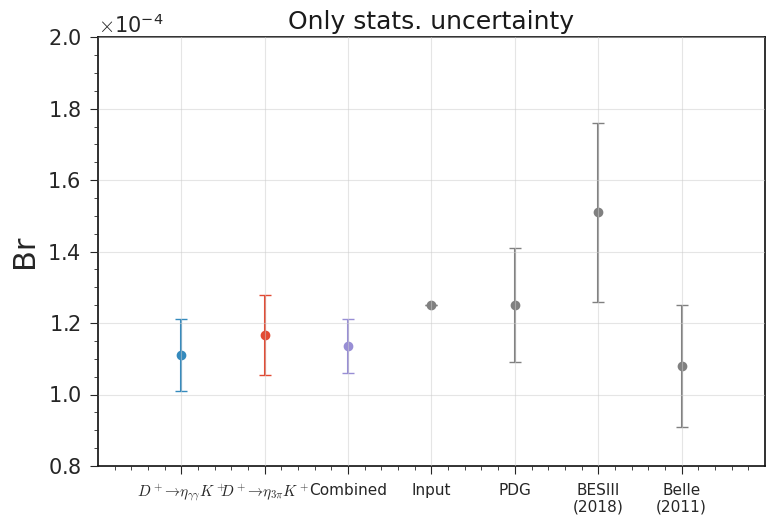

In [87]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)
plt.errorbar(4, Br_sig_dec, yerr=0, fmt='o', capsize=4, label='Input',color='gray')
plt.errorbar(5, Br_sig_PDG, yerr=Br_sig_PDG_err, fmt='o', capsize=4,color='gray')
plt.errorbar(6, 0.151/1000, yerr=0.025/1000, fmt='o', capsize=4,color='gray')
plt.errorbar(7, 1.08/10000, yerr=0.17/10000, fmt='o', capsize=4,color='gray')

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6, 7], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$', 'Combined','Input','PDG','BESIII\n(2018)','Belle\n(2011)'], fontsize=11)
# plt.xticks([1, 2, 3, 4], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$', 'Combined','Input','PDG'], fontsize=12)

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel('Br')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")
# plt.legend()
plt.tight_layout()
# plt.savefig("MC15rd_427_87_etaKp_gg_Br_fix_v7_bdt_Dp_CMS_p_new_range.best_Nsigma.weighted.png")
plt.savefig("MC15rd_427_87_etaKp_gg_Br_fix_v7_bdt_Dp_CMS_p_new_range.best_FOM.weighted.png")

plt.show()

# Br(Ds+ -> eta K+)

In [108]:
# Constants
Br_ref_dec = 0.017000000
Br_sig_dec = 0.001600000

Br_sig_PDG = 0.001730000
Br_sig_PDG_err = 0.000080000


In [109]:
# # 0.92
# eff_sig_cal =  0.035991
# eff_ref_cal =  0.050739

In [110]:
# 0.96
eff_sig_cal = 0.021185 
eff_ref_cal = 0.030647

In [111]:
eff_sig_err_cal = calculate_sig_eff_err(eff_sig_cal,  6e+6)
eff_ref_err_cal = calculate_sig_eff_err(eff_ref_cal, 6e+6)
print(f"signal eff error: {eff_sig_err_cal:.6e}, ref eff error: {eff_ref_err_cal:.6e}")

signal eff error: 5.878803e-05, ref eff error: 7.036543e-05


In [112]:
# First calculation for mode: eta -> gg
# Nsig_err, Nsig, Nref_err, Nref = 70.04074248014922,  2932.8851743349996,236.71727871748226 ,44928.70416190542
Nsig_err, Nsig, Nref_err, Nref =  49.68693891791986, 1739.3999761457335 , 179.75602070514287, 27226.604608274698

eff_sig_err, eff_sig, eff_ref_err, eff_ref = eff_sig_err_cal, eff_sig_cal, eff_ref_err_cal, eff_ref_cal

central_value_1 = calculate_br(Nsig, Nref, eff_sig, eff_ref, Br_ref_dec)
stat_unc_1 = calculate_stat_uncertainty(Nsig_err, Nsig, Nref_err, Nref, central_value_1)
print_results("Mode: eta -> gg", central_value_1, stat_unc_1, Br_sig_dec)

Mode: eta -> gg Central value = 1.5711e-03
Mode: eta -> gg Statistical uncertainty = 4.6064e-05
Mode: eta -> gg Pull = -0.6266
Mode: eta -> gg stas. unc./Central value = 2.9319e-02



In [113]:
# # 0.88
# eff_sig_cal  = 0.035896
# eff_ref_cal = 0.049895 

In [114]:
# 0.96
eff_sig_cal  =  0.013976
eff_ref_cal =  0.020936

In [115]:
eff_sig_err_cal = calculate_sig_eff_err(eff_sig_cal, 6e+6)
eff_sig_err_cal
# eff_ref_err_cal = calculate_sig_eff_err(0.02653, 2e+6)
eff_ref_err_cal = calculate_sig_eff_err(eff_ref_cal, 6e+6)

print(f"signal eff error: {eff_sig_err_cal:.6e}, ref eff error: {eff_ref_err_cal:.6e}")

signal eff error: 4.792472e-05, ref eff error: 5.844896e-05


In [116]:
# Second calculation for mode: eta -> pipipi
# Nsig_err, Nsig, Nref_err, Nref =  48.15500351924129, 1695.4630176977082, 171.24003642773096,25530.40137817878
Nsig_err, Nsig, Nref_err, Nref = 28.47466559697142,686.5911493079068, 108.8719350623478,10726.76158776726
eff_sig_err, eff_sig, eff_ref_err, eff_ref = eff_sig_err_cal, eff_sig_cal , eff_ref_err_cal, eff_ref_cal

central_value_2 = calculate_br(Nsig, Nref, eff_sig, eff_ref, Br_ref_dec)
stat_unc_2 = calculate_stat_uncertainty(Nsig_err, Nsig, Nref_err, Nref, central_value_2)
print_results("Mode: eta -> pipipi", central_value_2, stat_unc_2, Br_sig_dec)

Mode: eta -> pipipi Central value = 1.6300e-03
Mode: eta -> pipipi Statistical uncertainty = 6.9595e-05
Mode: eta -> pipipi Pull = 0.4312
Mode: eta -> pipipi stas. unc./Central value = 4.2696e-02



In [117]:
# Combined error-weighted result
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)
print_results("Combined", combined_central_value, combined_error, Br_sig_dec)

Combined Central value = 1.5891e-03
Combined Statistical uncertainty = 3.8412e-05
Combined Pull = -0.2845
Combined stas. unc./Central value = 2.4173e-02



In [118]:
(3.0974e-05-0.05/1000)/(0.05/1000)

-0.3805200000000001

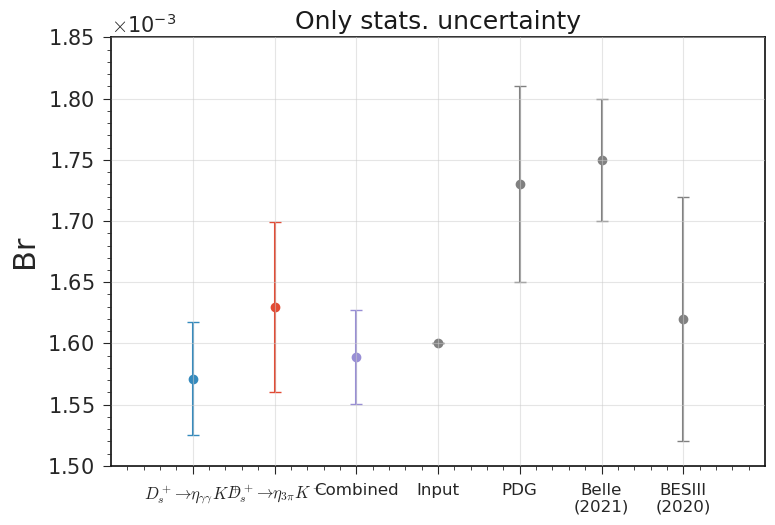

In [119]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)
plt.errorbar(4, Br_sig_dec, yerr=0, fmt='o', capsize=4, label='Input',color='gray')
plt.errorbar(5, Br_sig_PDG, yerr=Br_sig_PDG_err, fmt='o', capsize=4,color='gray')
plt.errorbar(6, 1.75/1000, yerr=0.05/1000, fmt='o', capsize=4,color='gray')
plt.errorbar(7, 1.62/1000, yerr=0.1/1000, fmt='o', capsize=4,color='gray')

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6, 7], [r'$D_s^+ \to \eta_{\gamma\gamma} K^+$', r'$D_s^+ \to \eta_{3\pi} K^+$', 'Combined','Input','PDG','Belle\n(2021)','BESIII\n(2020)'], fontsize=12)
# plt.xticks([1, 2, 3, 4], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$', 'Combined','Input','PDG'], fontsize=12)

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel('Br')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

# plt.legend()
plt.tight_layout()
# plt.savefig("MC15rd_427_87_etaKp_gg_Ds_Br_v7.png")
# plt.savefig("MC15rd_427_87_etaKp_gg_Ds_Br_fix_v7_bdt_Dp_CMS_p_new_range.best_Nsigma.weighted.png")
plt.savefig("MC15rd_427_87_etaKp_gg_Ds_Br_fix_v7_bdt_Dp_CMS_p_new_range.best_FOM.weighted.png")


plt.show()